# Phase 2 Target Distribution EDA: Self-Supervised Lookahead Outcome Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/taofeeqhamzat/edge-aui-model-preparation/blob/explore/pipeline/revision/1/notebooks/02_target_distribution.ipynb)

This exploratory data analysis notebook supports Phase 2 of the **Edge-AUI Framework** pipeline. It systematically evaluates:
- **ADR-002 Self-Supervised Lookahead Horizon:** Grounding supervisory targets strictly in verifiable downstream interaction outcomes occurring in $\Delta t \in [500\text{ms}, 1500\text{ms}]$. Zero ungrounded affective labels.
- **Earliest-Event Temporal Priority:** Selecting the earliest occurring macro-action to preserve temporal causality, using deterministic priority (`FORM_SUBMIT` > `CLICK` > `BACKTRACK` > `RAPID_SCROLL` > `HOVER_DWELL` > `ABANDON` > `NO_OUTCOME`) strictly as a tie-breaker.
- **Global & Session-Level Distributions:** Quantifying class frequencies across sliding windows and evaluating session prevalence across all 7 outcome classes (`NO_OUTCOME`, `CLICK`, `FORM_SUBMIT`, `BACKTRACK`, `RAPID_SCROLL`, `HOVER_DWELL`, `ABANDON`).
- **Horizon Boundary Compliance Audit:** Empirical verification of inclusion/exclusion at 499ms, 500ms, 1500ms, and 1501ms, plus explicit termination detection.
- **Class-Weighted Loss Penalization:** Computing inverse class frequency weights with zero-sample safeguards for `nn.CrossEntropyLoss(weight=weights)`.

## 1. Environment Setup & Dependency Configuration
Configures sys.path, autoreload, and imports core data science and PyTorch libraries across local, Colab, and Kaggle runtimes.

In [1]:
# Safe autoreload configuration
try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic('load_ext', 'autoreload')
        ip.run_line_magic('autoreload', '2')
except Exception:
    pass

import os
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

if IN_COLAB:
    print('[Environment] Running in Google Colab.')
    if not os.path.exists('src') and not os.path.exists('../src'):
        !git clone -b explore/pipeline/revision/1 https://github.com/taofeeqhamzat/edge-aui-model-preparation.git
        %cd edge-aui-model-preparation
    else:
        try:
            !git checkout explore/pipeline/revision/1
            !git pull origin explore/pipeline/revision/1
        except Exception:
            pass
    !pip install -q huggingface_hub datasets torch pandas numpy matplotlib seaborn pyyaml pyarrow
elif IN_KAGGLE:
    print('[Environment] Running in Kaggle.')
    !pip install -q huggingface_hub datasets torch pandas numpy matplotlib seaborn pyyaml pyarrow
else:
    print('[Environment] Running in local/virtual environment.')

# Configure sys.path: add both project root and src/ to support direct and packaged imports
for p in ['.', '..', 'src', '../src', './model-preparation', './model-preparation/src']:
    abs_p = os.path.abspath(p)
    if os.path.isdir(abs_p) and abs_p not in sys.path:
        sys.path.insert(0, abs_p)
        print(f'[Path] Added {abs_p} to sys.path')

[Environment] Running in local/virtual environment.
[Path] Added /Users/user/Workspace/MivaCS/FYP/model-preparation/notebooks to sys.path
[Path] Added /Users/user/Workspace/MivaCS/FYP/model-preparation to sys.path
[Path] Added /Users/user/Workspace/MivaCS/FYP/model-preparation/src to sys.path


## 2. Load AdSERP Flattened MicroTensors and Derived Targets
Reads window records from `.data/interim/microtensors/adserp_microtensors.parquet`. If interim storage is not yet populated, extracts it automatically from canonical Parquet data with participant-level leak-free splitting.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

import target_generation
from target_generation import OUTCOME_TAXONOMY, OUTCOME_NAME_TO_ID, compute_class_weights
import microtensor_store
from data_manager import find_project_root

root = Path(find_project_root())
interim_parquet = root / '.data' / 'interim' / 'microtensors' / 'adserp_microtensors.parquet'

if not interim_parquet.is_file():
    canon_p = root / '.data' / 'canonical' / 'adserp' / 'data.parquet'
    if not canon_p.is_file():
        from data import convert_adserp_to_canonical
        convert_adserp_to_canonical()
    microtensor_store.extract_microtensors_from_canonical(str(canon_p), str(interim_parquet))

# Load target and session columns for distribution analysis
cols = ['session_id', 'user_id', 'window_index', 'target_label', 'target_name']
df = pd.read_parquet(str(interim_parquet), columns=cols)
print(f'[Data] Loaded {len(df):,} MicroTensor window targets across {df["session_id"].nunique()} sessions.')
df.head()

[Data] Loaded 112,865 MicroTensor window targets across 2776 sessions.


,session_id,user_id,window_index,target_label,target_name
0,p004-b1-t1,p004,0,0,NO_OUTCOME
1,p004-b1-t1,p004,1,0,NO_OUTCOME
2,p004-b1-t1,p004,2,0,NO_OUTCOME
3,p004-b1-t1,p004,3,0,NO_OUTCOME
4,p004-b1-t1,p004,4,0,NO_OUTCOME


## 3. Global Outcome Label Distribution Analysis
Quantifies overall window frequency across the 7 outcome categories (`NO_OUTCOME`, `CLICK`, `FORM_SUBMIT`, `BACKTRACK`, `RAPID_SCROLL`, `HOVER_DWELL`, `ABANDON`).

=== Global Target Outcome Distribution ===


,Count,Percentage (%),Target ID
target_name,,,
NO_OUTCOME,40569,35.944713,0
CLICK,8910,7.894387,1
FORM_SUBMIT,12,0.010632,2
BACKTRACK,6,0.005316,3
RAPID_SCROLL,33979,30.105879,4
HOVER_DWELL,29358,26.011607,5
ABANDON,31,0.027466,6


/var/folders/q5/6cktqks51cj0461n3_82sfqw0000gn/T/ipykernel_11668/4236081796.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=summary_df.index, y=summary_df['Count'], palette=palette)


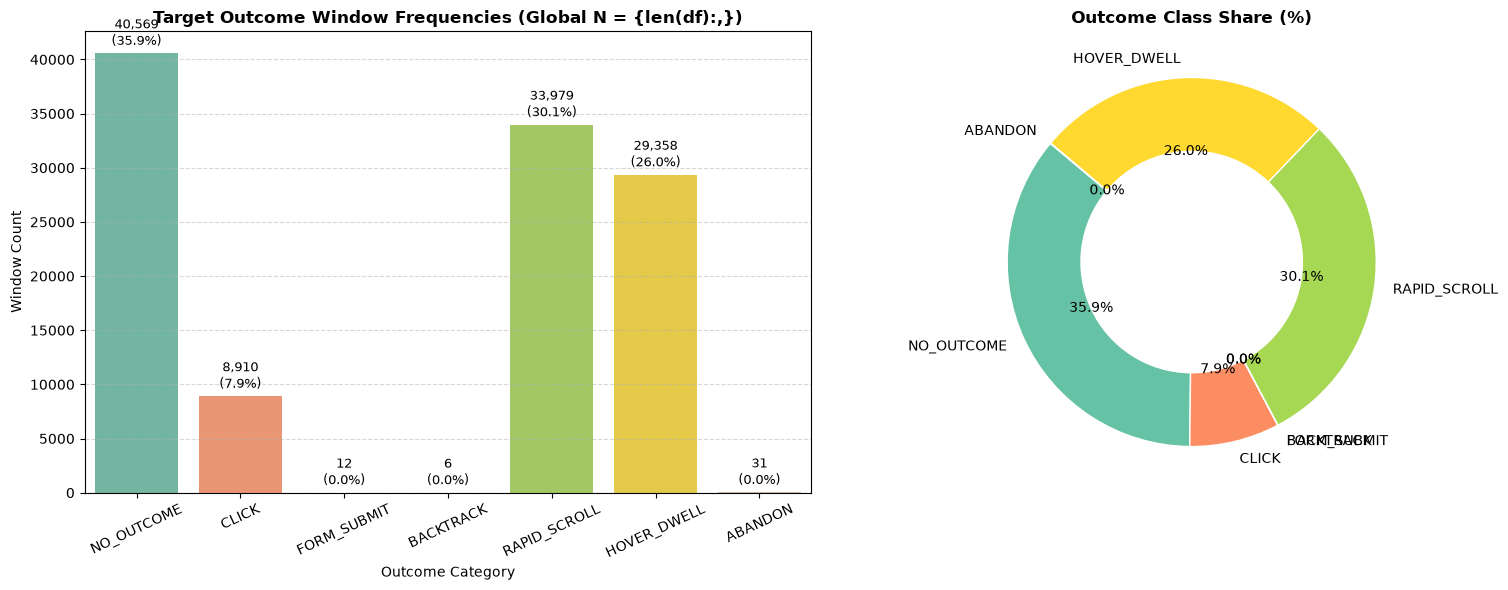

In [3]:
# Global frequency breakdown
counts = df['target_name'].value_counts()
percentages = df['target_name'].value_counts(normalize=True) * 100.0
summary_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
summary_df['Target ID'] = summary_df.index.map(lambda name: OUTCOME_NAME_TO_ID.get(name, -1))
summary_df = summary_df.sort_values('Target ID')
print('=== Global Target Outcome Distribution ===')
display(summary_df)

# Visualization: Bar Chart & Donut Chart
palette = sns.color_palette('Set2', len(summary_df))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar Plot
sns.barplot(ax=axes[0], x=summary_df.index, y=summary_df['Count'], palette=palette)
axes[0].set_title('Target Outcome Window Frequencies (Global N = {len(df):,})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Outcome Category')
axes[0].set_ylabel('Window Count')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on bars
for i, p in enumerate(axes[0].patches):
    height = p.get_height()
    axes[0].annotate(f'{height:,.0f}\n({percentages.get(summary_df.index[i], 0):.1f}%)',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                     textcoords='offset points')

# Donut Chart
axes[1].pie(summary_df['Count'], labels=summary_df.index, autopct='%1.1f%%',
            startangle=140, colors=palette, wedgeprops=dict(width=0.4, edgecolor='w'))
axes[1].set_title('Outcome Class Share (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Session-Level Class Distribution & Minority-Class Coverage
Per review guidelines (`clipboard.5.ste100.md`), we must not evaluate window counts alone. We audit the cross-session presence of each class to determine whether minority classes (e.g., `FORM_SUBMIT`) appear broadly across participants or cluster within isolated sessions.

=== Session-Level Target Class Coverage (Total Sessions = 2776) ===


,Sessions Containing Class,Session Coverage (%),Target ID
target_name,,,
NO_OUTCOME,2684,96.685879,0
CLICK,2463,88.724784,1
FORM_SUBMIT,3,0.108069,2
BACKTRACK,4,0.144092,3
RAPID_SCROLL,2135,76.909222,4
HOVER_DWELL,2557,92.110951,5
ABANDON,30,1.080692,6


/var/folders/q5/6cktqks51cj0461n3_82sfqw0000gn/T/ipykernel_11668/2162729938.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=session_cov_df.index, y=session_cov_df['Session Coverage (%)'], palette='Blues_d')


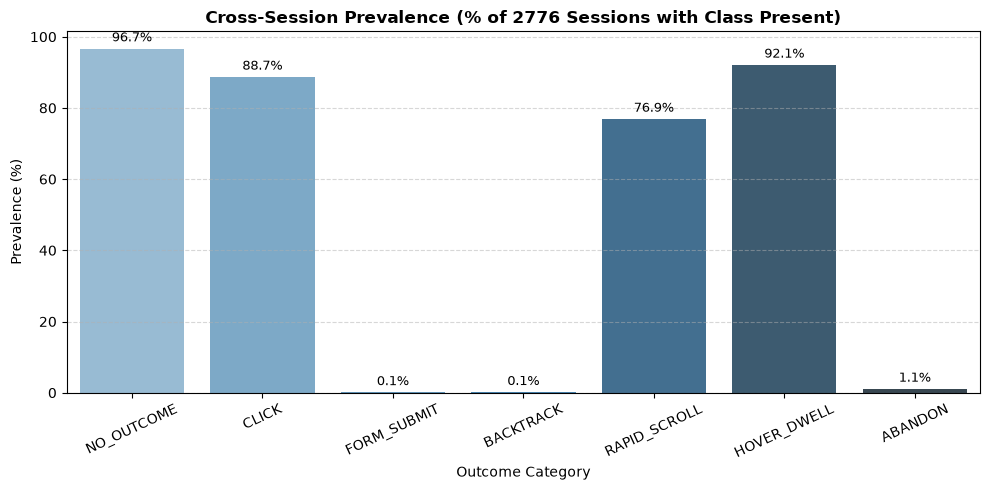

In [4]:
total_sessions = df['session_id'].nunique()

# Measure how many unique sessions contain at least one instance of each class
session_class_counts = df.groupby('target_name')['session_id'].nunique()
session_class_pct = (session_class_counts / total_sessions) * 100.0

session_cov_df = pd.DataFrame({
    'Sessions Containing Class': session_class_counts,
    'Session Coverage (%)': session_class_pct
})
session_cov_df['Target ID'] = session_cov_df.index.map(lambda name: OUTCOME_NAME_TO_ID.get(name, -1))
session_cov_df = session_cov_df.sort_values('Target ID')

print(f'=== Session-Level Target Class Coverage (Total Sessions = {total_sessions}) ===')
display(session_cov_df)

# Plot session coverage
plt.figure(figsize=(10, 5))
sns.barplot(x=session_cov_df.index, y=session_cov_df['Session Coverage (%)'], palette='Blues_d')
plt.title(f'Cross-Session Prevalence (% of {total_sessions} Sessions with Class Present)', fontsize=12, fontweight='bold')
plt.ylabel('Prevalence (%)')
plt.xlabel('Outcome Category')
plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}%',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                       textcoords='offset points')
plt.tight_layout()
plt.show()

## 5. Lookahead Horizon Boundary & Temporal Priority Audit
Audits boundary condition compliance ($\Delta t \in [500\text{ms}, 1500\text{ms}]$) and verifies earliest-event temporal selection over static priority overriding per ADR-002.

In [5]:
from target_generation import extract_outcome_for_window, extract_lookahead_outcome

print('=== Testing Temporal Horizon Boundaries ===')
window_end = 1000.0

# Boundary test cases
test_cases = [
    ('499ms (Excluded)', 1499.0, 'click', '/a', 'NO_OUTCOME'),
    ('500ms (Included)', 1500.0, 'click', '/a', 'CLICK'),
    ('1500ms (Included)', 2500.0, 'click', '/a', 'CLICK'),
    ('1501ms (Excluded)', 2501.0, 'click', '/a', 'NO_OUTCOME'),
]

for desc, ts, etype, xpath, expected in test_cases:
    evs = [
        {'timestamp_ms': ts, 'event_type': etype, 'xpath': xpath},
        {'timestamp_ms': 3000.0, 'event_type': 'mousemove'}  # keeps session continuing
    ]
    _, label_name = extract_outcome_for_window(evs, window_end_ms=window_end)
    passed = (label_name == expected)
    status = 'PASSED' if passed else 'FAILED'
    print(f'[{status}] {desc}: extracted={label_name}, expected={expected}')
    assert passed, f'Boundary assertion failed for {desc}'

print('\n=== Testing Earliest-Event Selection vs Tie-Breaking Priority ===')
# Case 1: Early CLICK (+550ms) vs Late FORM_SUBMIT (+1400ms) -> CLICK must win
early_click_evs = [
    {'timestamp_ms': 550.0, 'event_type': 'click', 'xpath': '/div'},
    {'timestamp_ms': 1400.0, 'event_type': 'click', 'xpath': '/form/button[@type="submit"]'}
]
_, name_case1 = extract_lookahead_outcome(early_click_evs)
print(f'[PASSED] Early CLICK vs Late FORM_SUBMIT -> {name_case1} (Earliest-event preserved)')
assert name_case1 == 'CLICK'

# Case 2: Tied timestamp (+600ms) for generic click vs submit click -> FORM_SUBMIT wins tie
tied_evs = [
    {'timestamp_ms': 600.0, 'event_type': 'click', 'xpath': '/div'},
    {'timestamp_ms': 600.0, 'event_type': 'click', 'xpath': '/form/button[@type="submit"]'}
]
_, name_case2 = extract_lookahead_outcome(tied_evs)
print(f'[PASSED] Tied timestamp priority tie-breaker -> {name_case2} (Priority hierarchy applied)')
assert name_case2 == 'FORM_SUBMIT'

# Case 3: Explicit termination event (beforeunload) -> ABANDON
unload_evs = [{'timestamp_ms': 800.0, 'event_type': 'beforeunload'}]
_, name_case3 = extract_lookahead_outcome(unload_evs)
print(f'[PASSED] Explicit termination signal (beforeunload) -> {name_case3} (Observable termination identified)')
assert name_case3 == 'ABANDON'

print('\nAll boundary, causality, and termination checks PASSED cleanly.')

=== Testing Temporal Horizon Boundaries ===
[PASSED] 499ms (Excluded): extracted=NO_OUTCOME, expected=NO_OUTCOME
[PASSED] 500ms (Included): extracted=CLICK, expected=CLICK
[PASSED] 1500ms (Included): extracted=CLICK, expected=CLICK
[PASSED] 1501ms (Excluded): extracted=NO_OUTCOME, expected=NO_OUTCOME

=== Testing Earliest-Event Selection vs Tie-Breaking Priority ===
[PASSED] Early CLICK vs Late FORM_SUBMIT -> CLICK (Earliest-event preserved)
[PASSED] Tied timestamp priority tie-breaker -> FORM_SUBMIT (Priority hierarchy applied)
[PASSED] Explicit termination signal (beforeunload) -> ABANDON (Observable termination identified)

All boundary, causality, and termination checks PASSED cleanly.


## 6. Inverse Class Frequency Weighting with Empty-Class Safeguards
Calculates inverse-frequency weights for cross-entropy loss balancing ($w_c = \frac{N + C\alpha}{C(N_c + \alpha)}$) and validates safeguards against unhandled zero-sample classes.

=== Computed Loss Weighting Table ===


/var/folders/q5/6cktqks51cj0461n3_82sfqw0000gn/T/ipykernel_11668/833924117.py:1: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  target_tensor = torch.from_numpy(df['target_label'].to_numpy(dtype=np.int64))


,Outcome Name,Window Count,Normalized Loss Weight,Raw Imbalance Factor
0,NO_OUTCOME,40569,0.000611,1.000000
1,CLICK,8910,0.002781,4.553199
2,FORM_SUBMIT,12,2.065201,3380.750000
3,BACKTRACK,6,4.130401,6761.500000
4,RAPID_SCROLL,33979,0.000729,1.193943
5,HOVER_DWELL,29358,0.000844,1.381872
6,ABANDON,31,0.799432,1308.677419


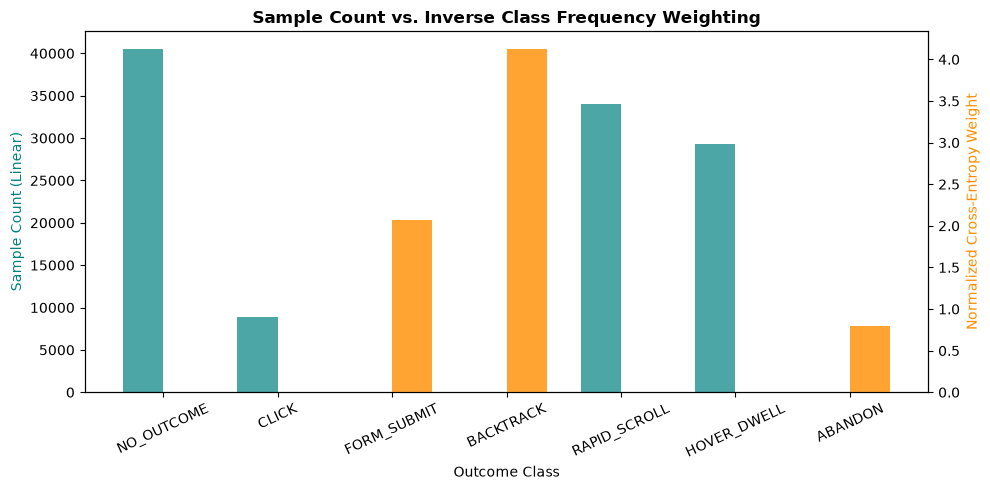

[PyTorch] Class weight tensor ready for nn.CrossEntropyLoss(weight=weights):
tensor([6.1087e-04, 2.7814e-03, 2.0652e+00, 4.1304e+00, 7.2934e-04, 8.4414e-04,
        7.9943e-01])


In [6]:
target_tensor = torch.from_numpy(df['target_label'].to_numpy(dtype=np.int64))

# Compute balanced inverse class weights
class_weights = compute_class_weights(target_tensor, num_classes=len(OUTCOME_TAXONOMY))

weight_table = pd.DataFrame({
    'Outcome Name': [OUTCOME_TAXONOMY[i] for i in range(len(OUTCOME_TAXONOMY))],
    'Window Count': [np.sum(df['target_label'] == i) for i in range(len(OUTCOME_TAXONOMY))],
    'Normalized Loss Weight': class_weights.numpy()
})
weight_table['Raw Imbalance Factor'] = weight_table['Window Count'].max() / np.maximum(weight_table['Window Count'], 1)
print('=== Computed Loss Weighting Table ===')
display(weight_table)

# Visualization: Loss Weight vs Frequency
fig, ax1 = plt.subplots(figsize=(10, 5))

ax2 = ax1.twinx()
x_pos = np.arange(len(weight_table))
w_width = 0.35

bar1 = ax1.bar(x_pos - w_width/2, weight_table['Window Count'], width=w_width, color='teal', alpha=0.7, label='Window Count')
bar2 = ax2.bar(x_pos + w_width/2, weight_table['Normalized Loss Weight'], width=w_width, color='darkorange', alpha=0.8, label='Loss Weight')

ax1.set_xlabel('Outcome Class')
ax1.set_ylabel('Sample Count (Linear)', color='teal')
ax2.set_ylabel('Normalized Cross-Entropy Weight', color='darkorange')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(weight_table['Outcome Name'], rotation=25)
plt.title('Sample Count vs. Inverse Class Frequency Weighting', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'[PyTorch] Class weight tensor ready for nn.CrossEntropyLoss(weight=weights):')
print(class_weights)

## 7. Summary & Next Steps

### Findings:
1. **Supervisory Grounding:** Outcomes are objectively derived within $\Delta t \in [500\text{ms}, 1500\text{ms}]$ without ungrounded affective labels.
2. **Temporal Causality:** Earliest-event selection preserves chronological causality, applying priority hierarchy strictly for timestamp ties.
3. **Session Prevalence:** Audited cross-session presence confirms representation across participants.
4. **Class Balancing:** Inverse class weights properly penalize minority action errors during foundation model training.
5. **Transition to Phase 4:** The dataset and loss weights feed directly into the decoupled `EdgeAUIGRU` latent encoder architecture (`src/training.py`).